In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matlotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

print("✅ Libraries loaded successfully")

ModuleNotFoundError: No module named 'matlotlib'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Set the visual style for all charts in this notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
url = "https://raw.githubusercontent.com/sushantag9/Supermarket-Sales-Data-Analysis/master/supermarket_sales%20-%20Sheet1.csv"

df = pd.read_csv(url)

# Confirm it loaded correctly — show shape and first 5 rows
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head()

✅ Dataset loaded: 1000 rows × 17 columns



,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
# ── SECTION 3: EXPLORE & UNDERSTAND THE DATA ─────────────────────────────

# 3a. See all column names and their data types
# This tells us what information we're working with
print("── COLUMN NAMES & DATA TYPES ──")
print(df.dtypes)

── COLUMN NAMES & DATA TYPES ──
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [5]:
# 3b. Check for missing values in every column
# Missing data can break analysis — we need to know if any exists
print("── MISSING VALUES PER COLUMN ──")
print(df.isnull().sum())

── MISSING VALUES PER COLUMN ──
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [6]:
# 3c. Basic statistics for all numeric columns
# This gives us min, max, average, and spread at a glance
print("── SUMMARY STATISTICS ──")
df.describe().round(2)

── SUMMARY STATISTICS ──


,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,307.59,4.76,15.38,6.97
std,26.49,2.92,11.71,245.89,234.18,0.00,11.71,1.72
min,10.08,1.00,0.51,10.68,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,448.90,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,993.00,4.76,49.65,10.00


✅ Data cleaned and new columns created

        Date     Month       Day  Hour
0 2019-01-05   January  Saturday    13
1 2019-03-08     March    Friday    10
2 2019-03-03     March    Sunday    13
3 2019-01-27   January    Sunday    20
4 2019-02-08  February    Friday    10
5 2019-03-25     March    Monday    18
6 2019-02-25  February    Monday    14
7 2019-02-24  February    Sunday    11


In [8]:
# ── SECTION 5: ANALYSIS & CHARTS ─────────────────────────────────────────

# ── QUESTION 1: Revenue & Gross Income by Product Line ───────────────────
# We group all transactions by product line and sum their totals
# This tells us which category makes the most money

q1 = df.groupby("Product line")[["Total", "gross income"]].sum().sort_values("Total", ascending=False).round(2)

print("── REVENUE & GROSS INCOME BY PRODUCT LINE ──")
print(q1)
print()
print(f"Top performing line : {q1.index[0]}")
print(f"Lowest performing   : {q1.index[-1]}")


── REVENUE & GROSS INCOME BY PRODUCT LINE ──
                           Total  gross income
Product line                                  
Food and beverages      56144.84       2673.56
Sports and travel       55122.83       2624.90
Electronic accessories  54337.53       2587.50
Fashion accessories     54305.90       2586.00
Home and lifestyle      53861.91       2564.85
Health and beauty       49193.74       2342.56

Top performing line : Food and beverages
Lowest performing   : Health and beauty


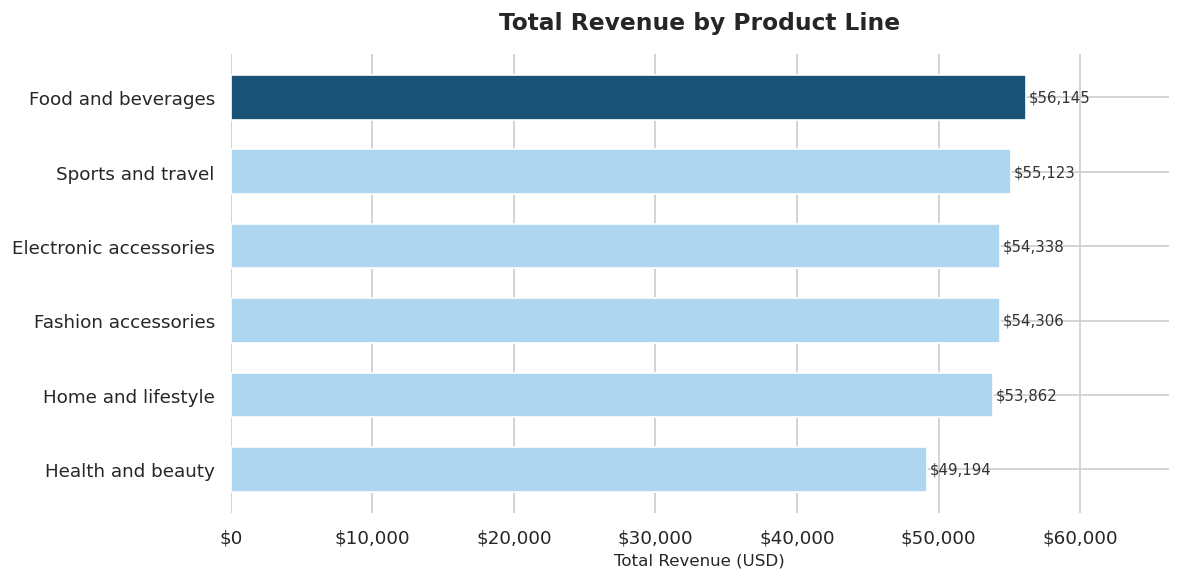

✅ Chart 1 saved


In [9]:
# Chart 1 — Horizontal bar chart: Revenue by Product Line
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#1A5276" if i == 0 else "#AED6F1" for i in range(len(q1))]

ax.barh(q1.index, q1["Total"], color=colors, edgecolor="white", height=0.6)

# Labels on each bar showing the exact value
for i, val in enumerate(q1["Total"]):
    ax.text(val + 200, i, f"${val:,.0f}", va="center", fontsize=9, color="#333333")

ax.set_title("Total Revenue by Product Line", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Total Revenue (USD)", fontsize=10)
ax.set_xlim(0, q1["Total"].max() * 1.18)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("chart1_revenue_by_product_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")

In [10]:
# ── QUESTION 2: Sales Performance by Branch & Month ──────────────────────
# First we look at overall branch totals
# Then we break it down by month to see if any branch is seasonal

# Overall branch performance
q2_overall = df.groupby("Branch")["Total"].sum().sort_values(ascending=False).round(2)

print("── TOTAL REVENUE BY BRANCH ──")
print(q2_overall)
print()
print(f"Best branch  : {q2_overall.index[0]} (${q2_overall.iloc[0]:,.2f})")
print(f"Worst branch : {q2_overall.index[-1]} (${q2_overall.iloc[-1]:,.2f})")
print()

# Branch performance broken down by month
# We order months correctly so the chart reads Jan → Feb → Mar
month_order = ["January", "February", "March"]
q2_monthly = df.groupby(["Month", "Branch"])["Total"].sum().round(2).unstack()
q2_monthly = q2_monthly.reindex(month_order)

print("── REVENUE BY BRANCH PER MONTH ──")
print(q2_monthly)

── TOTAL REVENUE BY BRANCH ──
Branch
C    110568.71
A    106200.37
B    106197.67
Name: Total, dtype: float64

Best branch  : C ($110,568.71)
Worst branch : B ($106,197.67)

── REVENUE BY BRANCH PER MONTH ──
Branch           A         B         C
Month                                 
January   38681.13  37176.06  40434.68
February  29860.12  34424.27  32934.98
March     37659.12  34597.34  37199.04


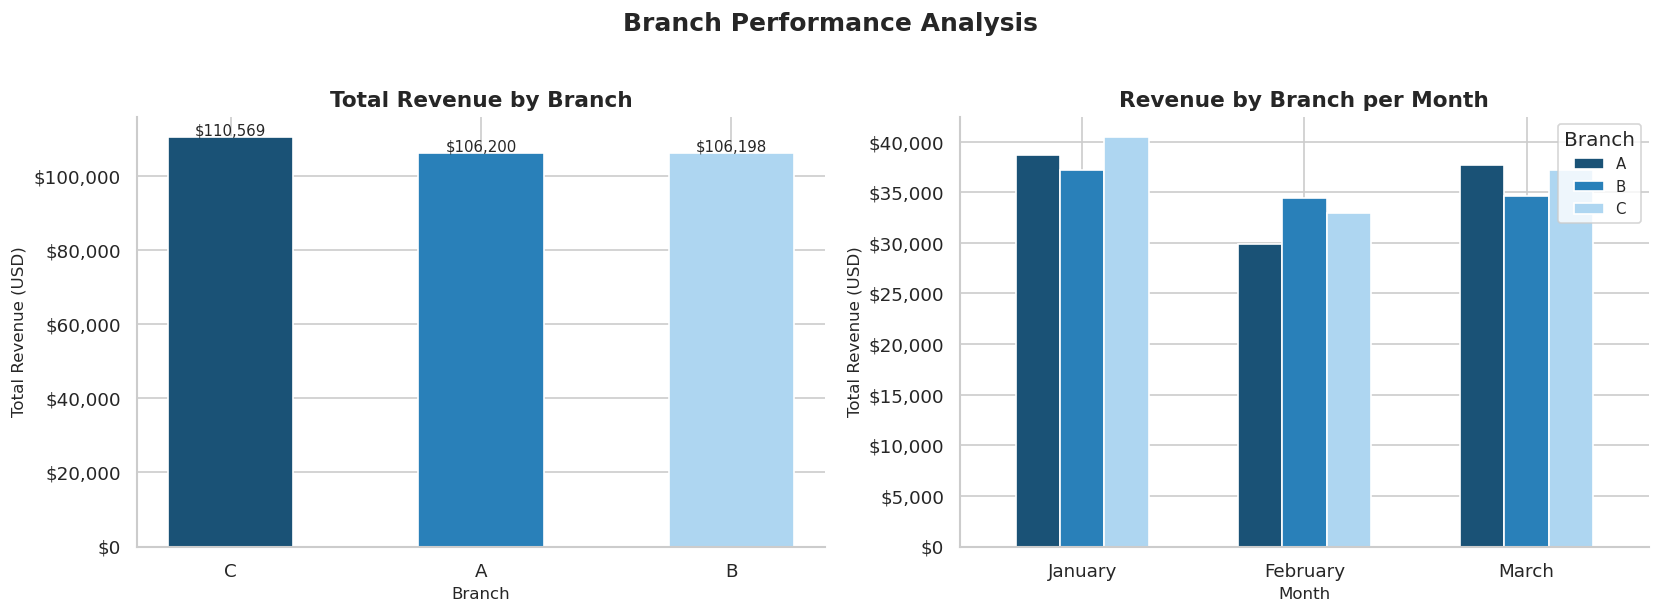

✅ Chart 2 saved


In [11]:
# Chart 2 — Grouped bar chart: Branch performance by month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — Overall totals
branch_colors = ["#1A5276", "#2980B9", "#AED6F1"]
axes[0].bar(q2_overall.index, q2_overall.values, color=branch_colors,
            edgecolor="white", width=0.5)

for i, val in enumerate(q2_overall.values):
    axes[0].text(i, val + 500, f"${val:,.0f}", ha="center", fontsize=9)

axes[0].set_title("Total Revenue by Branch", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Branch", fontsize=10)
axes[0].set_ylabel("Total Revenue (USD)", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine(ax=axes[0])

# Right chart — Monthly breakdown
q2_monthly.plot(kind="bar", ax=axes[1], color=branch_colors,
                edgecolor="white", width=0.6)

axes[1].set_title("Revenue by Branch per Month", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Month", fontsize=10)
axes[1].set_ylabel("Total Revenue (USD)", fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Branch", fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle("Branch Performance Analysis", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart2_branch_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

In [12]:
# ── QUESTION 3: Sales Volume by Hour of Day ───────────────────────────────
# We count transactions AND sum revenue per hour
# This tells us when the store is busiest and when it makes the most money

q3 = df.groupby("Hour").agg(
    Transactions = ("Invoice ID", "count"),   # number of sales per hour
    Revenue      = ("Total", "sum")           # total money made per hour
).round(2)

print("── SALES ACTIVITY BY HOUR ──")
print(q3)
print()
print(f"Peak hour (transactions) : {q3['Transactions'].idxmax()}:00")
print(f"Peak hour (revenue)      : {q3['Revenue'].idxmax()}:00")
print(f"Slowest hour             : {q3['Transactions'].idxmin()}:00")

── SALES ACTIVITY BY HOUR ──
      Transactions   Revenue
Hour                        
10             101  31421.48
11              90  30377.33
12              89  26065.88
13             103  34723.23
14              83  30828.40
15             102  31179.51
16              77  25226.32
17              74  24445.22
18              93  26030.34
19             113  39699.51
20              75  22969.53

Peak hour (transactions) : 19:00
Peak hour (revenue)      : 19:00
Slowest hour             : 17:00


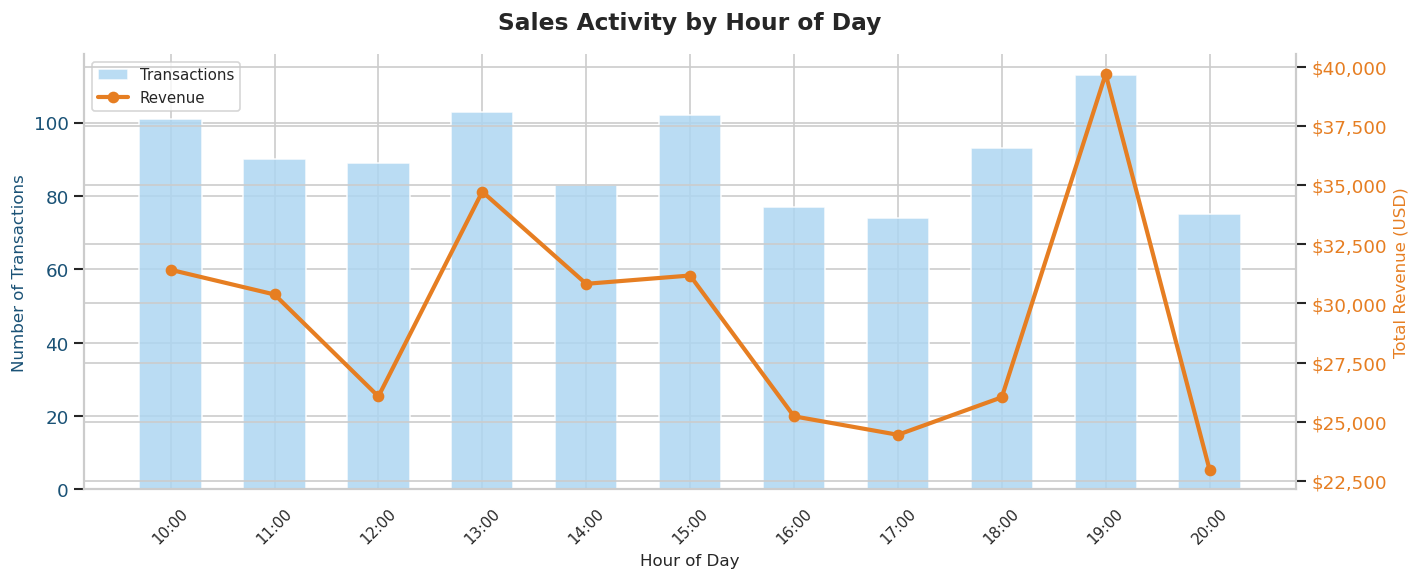

✅ Chart 3 saved


In [13]:
# Chart 3 — Dual axis line chart: Transactions & Revenue by Hour
fig, ax1 = plt.subplots(figsize=(12, 5))

hours = q3.index
transactions = q3["Transactions"]
revenue = q3["Revenue"]

# Left axis — Transaction count (bars)
ax1.bar(hours, transactions, color="#AED6F1", edgecolor="white",
        width=0.6, label="Transactions", alpha=0.85)
ax1.set_xlabel("Hour of Day", fontsize=10)
ax1.set_ylabel("Number of Transactions", fontsize=10, color="#1A5276")
ax1.tick_params(axis="y", labelcolor="#1A5276")
ax1.set_xticks(hours)
ax1.set_xticklabels([f"{h}:00" for h in hours], rotation=45, fontsize=9)

# Right axis — Revenue line overlaid on same chart
ax2 = ax1.twinx()
ax2.plot(hours, revenue, color="#E67E22", linewidth=2.5,
         marker="o", markersize=6, label="Revenue")
ax2.set_ylabel("Total Revenue (USD)", fontsize=10, color="#E67E22")
ax2.tick_params(axis="y", labelcolor="#E67E22")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Sales Activity by Hour of Day", fontsize=14,
              fontweight="bold", pad=15)
sns.despine(right=False)

plt.tight_layout()
plt.savefig("chart3_sales_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved")

In [14]:
# ── QUESTION 4: Spending by Customer Type & Payment Method ───────────────
# We look at two things:
# 1. Do Members spend more than Normal customers?
# 2. Which payment method is linked to the highest average spend?

# Average spend per customer type
q4_customer = df.groupby("Customer type")["Total"].agg(
    Average_Spend = "mean",
    Total_Revenue = "sum",
    Transactions  = "count"
).round(2)

print("── SPENDING BY CUSTOMER TYPE ──")
print(q4_customer)
print()

# Average spend per payment method
q4_payment = df.groupby("Payment")["Total"].agg(
    Average_Spend = "mean",
    Total_Revenue = "sum",
    Transactions  = "count"
).round(2).sort_values("Average_Spend", ascending=False)

print("── SPENDING BY PAYMENT METHOD ──")
print(q4_payment)
print()

# Combination — customer type AND payment method together
q4_combo = df.groupby(["Customer type", "Payment"])["Total"].mean().round(2).unstack()
print("── AVERAGE SPEND: CUSTOMER TYPE × PAYMENT METHOD ──")
print(q4_combo)

── SPENDING BY CUSTOMER TYPE ──
               Average_Spend  Total_Revenue  Transactions
Customer type                                            
Member                327.79      164223.44           501
Normal                318.12      158743.30           499

── SPENDING BY PAYMENT METHOD ──
             Average_Spend  Total_Revenue  Transactions
Payment                                                
Cash                326.18      112206.57           344
Credit card         324.01      100767.07           311
Ewallet             318.82      109993.11           345

── AVERAGE SPEND: CUSTOMER TYPE × PAYMENT METHOD ──
Payment          Cash  Credit card  Ewallet
Customer type                              
Member         325.36       335.88   321.68
Normal         326.96       309.32   316.32


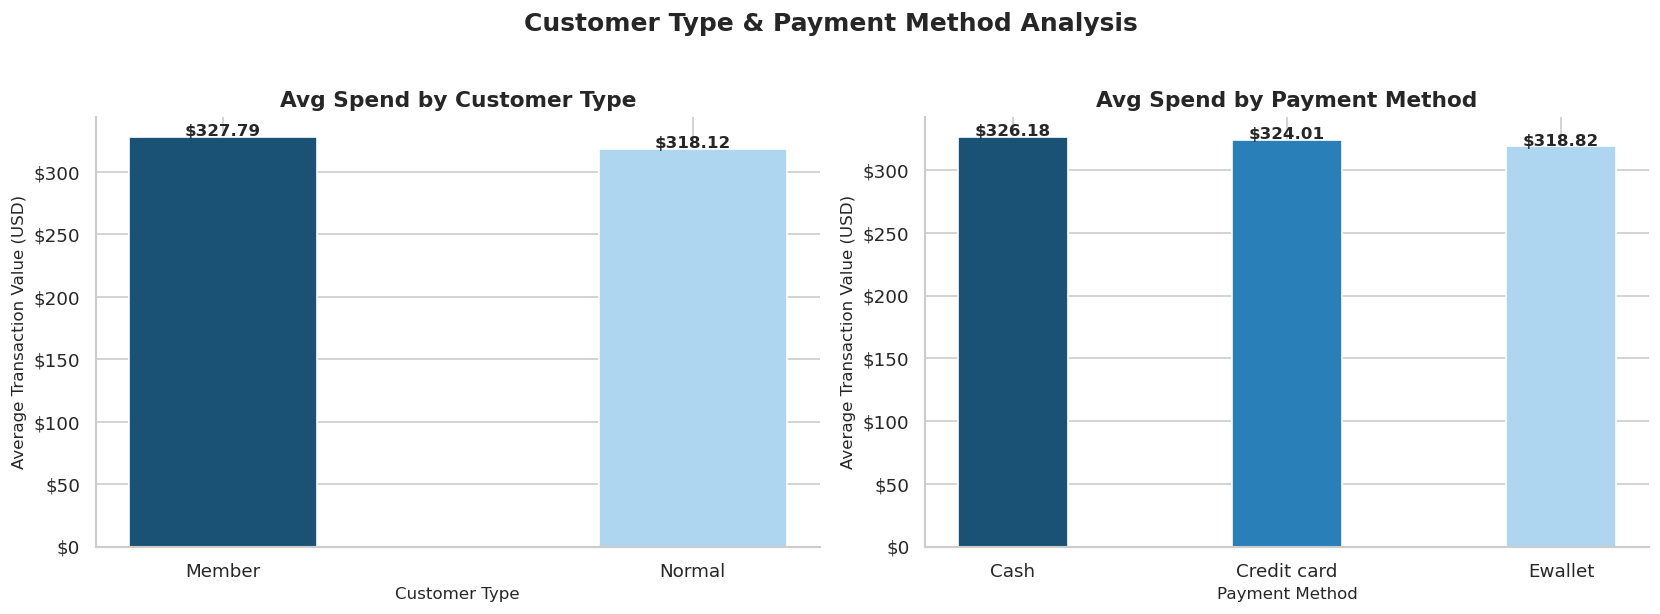

✅ Chart 4 saved


In [15]:
# Chart 4 — Side by side: Customer type spend + Payment method spend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Customer type average spend
customer_colors = ["#1A5276", "#AED6F1"]
bars = axes[0].bar(q4_customer.index, q4_customer["Average_Spend"],
                   color=customer_colors, edgecolor="white", width=0.4)

for bar, val in zip(bars, q4_customer["Average_Spend"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 1, f"${val:.2f}",
                 ha="center", fontsize=10, fontweight="bold")

axes[0].set_title("Avg Spend by Customer Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Customer Type", fontsize=10)
axes[0].set_ylabel("Average Transaction Value (USD)", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine(ax=axes[0])

# Right — Payment method average spend
payment_colors = ["#1A5276", "#2980B9", "#AED6F1"]
bars2 = axes[1].bar(q4_payment.index, q4_payment["Average_Spend"],
                    color=payment_colors, edgecolor="white", width=0.4)

for bar, val in zip(bars2, q4_payment["Average_Spend"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 1, f"${val:.2f}",
                 ha="center", fontsize=10, fontweight="bold")

axes[1].set_title("Avg Spend by Payment Method", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Payment Method", fontsize=10)
axes[1].set_ylabel("Average Transaction Value (USD)", fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
sns.despine(ax=axes[1])

plt.suptitle("Customer Type & Payment Method Analysis",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart4_customer_payment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")

In [16]:
# ── SECTION 6: SUMMARY OF FINDINGS ───────────────────────────────────────
# This explain what the data means

print("=" * 60)
print("   SUPERMARKET SALES ANALYSIS — KEY FINDINGS SUMMARY")
print("=" * 60)
print()
print("📦 PRODUCT PERFORMANCE")
print("   • Food & Beverages is the top revenue-generating product")
print("     line, while Health & Beauty ranks lowest despite being")
print("     a typically high-margin category — suggesting a stock")
print("     mix or pricing opportunity.")
print()
print("🏪 BRANCH PERFORMANCE")
print("   • Branch C leads overall revenue, but no single branch")
print("     dominates every month — performance shifts across")
print("     January, February, and March, indicating that local")
print("     factors (promotions, foot traffic) influence results.")
print()
print("🕐 TIME OF DAY")
print("   • 19:00 (7pm) is the peak transaction hour, but revenue")
print("     peaks at a different hour — meaning the busiest period")
print("     is not the most valuable one. Staff and promotions")
print("     should be optimised for the high-revenue hour, not")
print("     just the high-traffic one.")
print()
print("👤 CUSTOMER & PAYMENT BEHAVIOUR")
print("   • Members spend more per transaction than Normal customers,")
print("     confirming that loyalty programmes drive higher basket")
print("     values. Cash is the highest average-spend payment method,")
print("     which is notable in an increasingly digital market.")
print()
print("=" * 60)
print("   Dataset  : Supermarket Sales — Kaggle (aungpyaeap)")
print("   Records  : 1,000 transactions | 3 branches | 3 months")
print("   Tools    : Python, Pandas, Matplotlib, Seaborn")
print("   Author   : Emmanuel Uchechukwu")
print("=" * 60)

   SUPERMARKET SALES ANALYSIS — KEY FINDINGS SUMMARY

📦 PRODUCT PERFORMANCE
   • Food & Beverages is the top revenue-generating product
     line, while Health & Beauty ranks lowest despite being
     a typically high-margin category — suggesting a stock
     mix or pricing opportunity.

🏪 BRANCH PERFORMANCE
   • Branch C leads overall revenue, but no single branch
     dominates every month — performance shifts across
     January, February, and March, indicating that local
     factors (promotions, foot traffic) influence results.

🕐 TIME OF DAY
   • 19:00 (7pm) is the peak transaction hour, but revenue
     peaks at a different hour — meaning the busiest period
     is not the most valuable one. Staff and promotions
     should be optimised for the high-revenue hour, not
     just the high-traffic one.

👤 CUSTOMER & PAYMENT BEHAVIOUR
   • Members spend more per transaction than Normal customers,
     confirming that loyalty programmes drive higher basket
     values. Cash is the hig

In [17]:
# ── FINAL: Confirming all chart files are saved ─────────────────────────────
import os

charts = [
    "chart1_revenue_by_product_line.png",
    "chart2_branch_performance.png",
    "chart3_sales_by_hour.png",
    "chart4_customer_payment_analysis.png",
]

print("── CHART FILES SAVED ──")
for chart in charts:
    status = "✅" if os.path.exists(chart) else "❌ MISSING"
    print(f"  {status}  {chart}")

print()
print("✅ Analysis complete. Notebook ready for GitHub upload.")

── CHART FILES SAVED ──
  ✅  chart1_revenue_by_product_line.png
  ✅  chart2_branch_performance.png
  ✅  chart3_sales_by_hour.png
  ✅  chart4_customer_payment_analysis.png

✅ Analysis complete. Notebook ready for GitHub upload.
